## Homework 3 (you need to complete this homework or Project).

#### Source with comments : http://blog.ethanrosenthal.com/2016/01/09/explicit-matrix-factorization-sgd-als/
#### 1. Compare recommendations quality and inference time for ALS (Alternating Least Squares without biases) and SGD (Stochastic Gradient Descent without biases) using different regularization values (0.001, 0.01, ...) and factors (1, 10, 25, 50, ...). Improve the code to implement SGD.

#### 2. Change the ALS code so it can perform calculations with biases. Decent instructions can be found here: http://activisiongamescience.github.io/2016/01/11/Implicit-Recommender-Systems-Biased-Matrix-Factorization/.

#### 3. Compare all 4 approaches by MSE, training time, inference time. Put your results (in addition to ipython cells runs) in a summary table. Make qualitative conclusions.

#### 4. Make your own explanation why this ALS implementation does not work good w.r.t. MSE. Try to enhance it if possible or compare it with other implementation(s) (e.g., ALS from Apache Spark MLlib).

#### Data source: MovieLens 100k. You can choose another dataset, but it cannot have smaller number of ratings or users and items.

#### Send your reports to dmitrii.ignatov@gmail.com with obligatory CC to dvpozdnyakov@hse.ru. Topic:  [RecSys4DS2024-HW3]-<LastName_FirstName>

#### Soft Deadline: 7.12.2024

#### Hard Deadline: 9.12.2024


The model loss function:

$L = \sum\limits_{u,i}(r_{ui} - (\mu + b_{u} + b_{i} + \textbf{x}_{u}^{\intercal} \cdot{} \textbf{y}_{i}))^{2}$+$\lambda_{xb} \sum\limits_{u} \left\Vert b_{u} \right\Vert^{2} + \lambda_{yb}\sum\limits_{i} \left\Vert b_{i} \right\Vert^{2}+
\lambda_{xf} \sum\limits_{u} \left\Vert \textbf{x}_{u} \right\Vert^{2} + \lambda_{yf} \sum\limits_{i} \left\Vert \textbf{y}_{i} \right\Vert^{2}$

In [1]:
import numpy as np
import pandas as pd
np.random.seed(0)

MovieLens dataset


In [ ]:
# cd ml-100k/

[Error 2] : u'ml-100k/'
C:\Users\Administrator\Dropbox\MLDM Course\Рекомендательные системы\MF scripts\ml-100k


### Load data and create ratings matrix $r_{ij}$

In [2]:
# Load dataset
names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('./u.data', sep='\t', names=names)
n_users = df.user_id.unique().shape[0]
n_items = df.item_id.unique().shape[0]

# Create r_{ui}, our ratings matrix
ratings = np.zeros((n_users, n_items))
for row in df.itertuples():
    ratings[row[1]-1, row[2]-1] = row[3]

### Split test and train

In [3]:
# Split into training and test sets.
# Remove 10 ratings for each user and assign them to the test set
def train_test_split(ratings):
    test = np.zeros(ratings.shape)
    train = ratings.copy()
    for user in np.arange(ratings.shape[0]):
        test_ratings = np.random.choice(ratings[user, :].nonzero()[0],
                                        size=10,
                                        replace=False)
        train[user, test_ratings] = 0.
        test[user, test_ratings] = ratings[user, test_ratings]

    # Test and training are truly disjoint
    assert(np.all((train * test) == 0))
    return train, test

### Metric

In [4]:
from sklearn.metrics import mean_squared_error

def get_mse(pred, actual):
    pred = pred[actual.nonzero()].flatten()
    actual = actual[actual.nonzero()].flatten()
    return mean_squared_error(pred, actual)

### Class implementing ALS and ExplicitMF with gradient descent and biases

In [ ]:
from numpy.linalg import solve


class ExplicitMF():
    def __init__(self,
                 ratings,
                 n_factors=40,
                 learning='sgd',
                 item_fact_reg=0.0,
                 user_fact_reg=0.0,
                 item_bias_reg=0.0,
                 user_bias_reg=0.0,
                 verbose=False,
                 bias_use=False):
        """
        Train a matrix factorization model to predict empty
        entries in a matrix. The terminology assumes a
        ratings matrix which is ~ user x item

        Params
        ======
        ratings : (ndarray)
            User x Item matrix with corresponding ratings

        n_factors : (int)
            Number of latent factors to use in matrix
            factorization model
        learning : (str)
            Method of optimization. Options include
            'sgd' or 'als'.

        item_fact_reg : (float)
            Regularization term for item latent factors

        user_fact_reg : (float)
            Regularization term for user latent factors

        item_bias_reg : (float)
            Regularization term for item biases

        user_bias_reg : (float)
            Regularization term for user biases

        verbose : (bool)
            Whether or not to printout training progress

        bias_use : (bool)
            Whether or not to add bias in training progress
        """

        self.ratings = ratings
        self.n_users, self.n_items = ratings.shape
        self.n_factors = n_factors
        self.item_fact_reg = item_fact_reg
        self.user_fact_reg = user_fact_reg
        self.item_bias_reg = item_bias_reg
        self.user_bias_reg = user_bias_reg
        self.learning = learning
        if self.learning == 'sgd':
            self.sample_row, self.sample_col = self.ratings.nonzero()
            self.n_samples = len(self.sample_row)
        self._v = verbose
        self.bias_use = bias_use

    def als_step(self,
                 latent_vectors,
                 fixed_vecs,
                 ratings,
                 _lambda,
                 type='user'):
        """
        One of the two ALS steps. Solve for the latent vectors
        specified by type.
        """
        if type == 'user':
            # Precompute
            if self.bias_use:
                ratings = ratings - self.item_bias
                fixed_vecs = np.hstack([np.ones([fixed_vecs.shape[0], 1], dtype=np.float32), fixed_vecs]) # (1, XT)

                # add dimension for future user_bias
                latent_vectors = np.hstack([np.ones([latent_vectors.shape[0], 1], dtype=np.float32), latent_vectors])

            YTY = fixed_vecs.T.dot(fixed_vecs)
            lambdaI = np.eye(YTY.shape[0]) * _lambda

            for u in range(latent_vectors.shape[0]):
                latent_vectors[u, :] = solve((YTY + lambdaI),
                                             ratings[u, :].dot(fixed_vecs))

            # separation of user_bias and latent vector for common dimension of gloabal solution
            if self.bias_use:
                self.user_bias = latent_vectors[:, 0]
                latent_vectors = latent_vectors[:, 1:]

        elif type == 'item':
            # Precompute
            if self.bias_use:
                ratings -= self.user_bias[:, None]
                fixed_vecs = np.hstack([np.ones([fixed_vecs.shape[0], 1], dtype=np.float32), fixed_vecs]) # (1, YT)

                # add dimension for future item_bias
                latent_vectors = np.hstack([np.ones([latent_vectors.shape[0], 1], dtype=np.float32), latent_vectors])

            XTX = fixed_vecs.T.dot(fixed_vecs)
            lambdaI = np.eye(XTX.shape[0]) * _lambda

            for i in range(latent_vectors.shape[0]):
                latent_vectors[i, :] = solve((XTX + lambdaI),
                                             ratings[:, i].T.dot(fixed_vecs))

            # separation of item_bias and latent vector for common dimension of gloabal solution
            if self.bias_use:
                self.item_bias = latent_vectors[:, 0]
                latent_vectors = latent_vectors[:, 1:]

        return latent_vectors

    def train(self, n_iter=10, learning_rate=0.1):
        """ Train model for n_iter iterations from scratch."""
        # initialize latent vectors
        self.user_vecs = np.random.normal(scale=1./self.n_factors, size=(self.n_users, self.n_factors))
        self.item_vecs = np.random.normal(scale=1./self.n_factors, size=(self.n_items, self.n_factors))

        if self.bias_use:
            self.user_bias = np.zeros(self.n_users)
            self.item_bias = np.zeros(self.n_items)
            self.global_bias = np.mean(self.ratings[np.where(self.ratings != 0)]) # only for sgd

        if self.learning == 'als':
            self.partial_train(n_iter,0)
        elif self.learning == 'sgd':
            self.learning_rate = learning_rate
            self.partial_train(n_iter, 0)


    def partial_train(self, n_iter, iter_done):
        """
        Train model for n_iter iterations. Can be
        called multiple times for further training.
        """
        ctr = 1
        while ctr <= n_iter:
            if (ctr+iter_done) % 10 == 0 and self._v:
                print (f'\tcurrent iteration: {ctr+iter_done}')
            if self.learning == 'als':
                self.user_vecs = self.als_step(self.user_vecs,
                                               self.item_vecs,
                                               self.ratings,
                                               self.user_fact_reg,
                                               type='user')
                self.item_vecs = self.als_step(self.item_vecs,
                                               self.user_vecs,
                                               self.ratings,
                                               self.item_fact_reg,
                                               type='item')
            elif self.learning == 'sgd':
                self.training_indices = np.arange(self.n_samples)
                np.random.shuffle(self.training_indices)
                self.sgd()
            ctr += 1

    def sgd(self):
        for idx in self.training_indices:
            u = self.sample_row[idx]
            i = self.sample_col[idx]
            prediction = self.predict(u, i)
            e = (self.ratings[u,i] - prediction) # error

            # Update biases
            if self.bias_use:
                self.user_bias[u] += self.learning_rate * (e - self.user_bias_reg * self.user_bias[u])
                self.item_bias[i] += self.learning_rate * (e - self.item_bias_reg * self.item_bias[i])

            #Update latent factors
            self.user_vecs[u, :] += self.learning_rate *\
                                    (e * self.item_vecs[i, :] - self.user_fact_reg * self.user_vecs[u,:])
            self.item_vecs[i, :] += self.learning_rate * \
                                    (e * self.user_vecs[u, :] - self.item_fact_reg * self.item_vecs[i,:])
    def predict(self, u, i):
        """ Single user and item prediction."""
        if self.learning == 'als':
            if self.bias_use:
                # adding bias component
                return self.user_vecs[u, :].dot(self.item_vecs[i, :].T) + self.item_bias[i] + self.user_bias[u]
            return self.user_vecs[u, :].dot(self.item_vecs[i, :].T)
        elif self.learning == 'sgd':
            if self.bias_use:
                prediction = self.global_bias + self.user_bias[u] + self.item_bias[i]
                prediction += self.user_vecs[u, :].dot(self.item_vecs[i, :].T)
            else:
                prediction = self.user_vecs[u, :].dot(self.item_vecs[i, :].T)
            return prediction

    def predict_all(self):
        """ Predict ratings for every user and item."""
        predictions = np.zeros((self.user_vecs.shape[0],
                                self.item_vecs.shape[0]))
        for u in range(self.user_vecs.shape[0]):
            for i in range(self.item_vecs.shape[0]):
                predictions[u, i] = self.predict(u, i)

        return predictions

    def calculate_learning_curve(self, iter_array, test, learning_rate=0.1):
        """
        Keep track of MSE as a function of training iterations.

        Params
        ======
        iter_array : (list)
            List of numbers of iterations to train for each step of
            the learning curve. e.g. [1, 5, 10, 20]
        test : (2D ndarray)
            Testing dataset (assumed to be user x item).

        The function creates two new class attributes:

        train_mse : (list)
            Training data MSE values for each value of iter_array
        test_mse : (list)
            Test data MSE values for each value of iter_array
        """
        iter_array.sort()
        self.train_mse =[]
        self.test_mse = []
        iter_diff = 0
        for (i, n_iter) in enumerate(iter_array):
            if self._v:
                print (f'Iteration: {n_iter}')
            if i == 0:
                self.train(n_iter - iter_diff, learning_rate)
            else:
                self.partial_train(n_iter - iter_diff, iter_diff)

            predictions = self.predict_all()

            self.train_mse += [get_mse(predictions, self.ratings)]
            self.test_mse += [get_mse(predictions, test)]
            if self._v:
                print (f'MSE train:test: {round(self.train_mse[-1],2)} : {round(self.test_mse[-1],2)}\n')
            iter_diff = n_iter

#### Plots

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

def plot_learning_curve(iter_array, model):
    plt.plot(iter_array, model.train_mse, \
             label='Training', linewidth=3)
    plt.plot(iter_array, model.test_mse, \
             label='Test', linewidth=3)


    plt.xticks(fontsize=16);
    plt.yticks(fontsize=16);
    plt.xlabel('Iterations', fontsize=25);
    plt.ylabel('MSE', fontsize=25);
    plt.legend(loc='best', fontsize=20);

In [13]:
train, test = train_test_split(ratings)

#### Gradient descent without biases

In [ ]:
import time

start_time = time.time()

MF_SGD = ExplicitMF(train, 40, learning='sgd', verbose=True, item_fact_reg=0.01,
                                                             user_fact_reg=0.01,
                                                             item_bias_reg=0.01,
                                                             user_bias_reg=0.01, bias_use=False)
iter_array = [1, 2, 5, 10, 25]
MF_SGD.calculate_learning_curve(iter_array, test, learning_rate=0.001)

end_time = time.time()

print("time: ", end_time - start_time)

Iteration: 1
MSE train:test: 13.69 : 14.1

Iteration: 2
MSE train:test: 13.68 : 14.1

Iteration: 5
MSE train:test: 13.62 : 14.06

Iteration: 10
	current iteration: 10
MSE train:test: 6.52 : 9.45

Iteration: 25
	current iteration: 20
MSE train:test: 1.17 : 2.01

time:  58.77985072135925


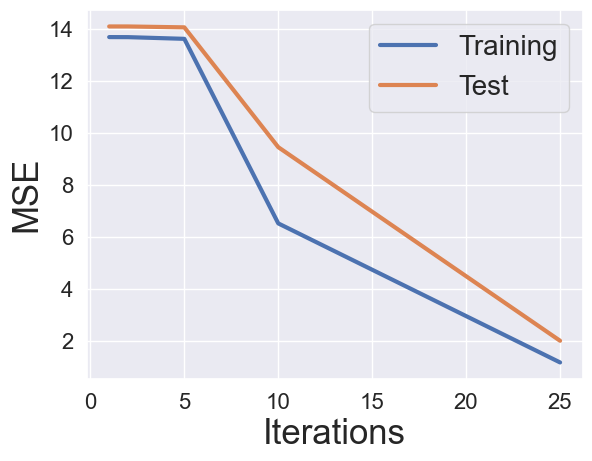

In [ ]:
plot_learning_curve(iter_array, MF_SGD)

In [ ]:
# Loss function shows us stable proccess of learning. This method just need more epochs. 
# As we see in the next chapter bias can make huge impact to increase the speed of learning and improve metric mse

##### Gradient descent with biases

In [ ]:
start_time = time.time()
MF_SGD = ExplicitMF(train, 40, learning='sgd', verbose=True, item_fact_reg=0.01,
                                                             user_fact_reg=0.01,
                                                             item_bias_reg=0.01,
                                                             user_bias_reg=0.01, bias_use=True)
iter_array = [1, 2, 5, 10, 25]
MF_SGD.calculate_learning_curve(iter_array, test, learning_rate=0.001)

end_time = time.time()

print("time: ", end_time - start_time)

Iteration: 1
MSE train:test: 1.14 : 1.19

Iteration: 2
MSE train:test: 1.07 : 1.14

Iteration: 5
MSE train:test: 0.98 : 1.06

Iteration: 10
	current iteration: 10
MSE train:test: 0.92 : 1.02

Iteration: 25
	current iteration: 20
MSE train:test: 0.87 : 0.97

time:  66.90599822998047


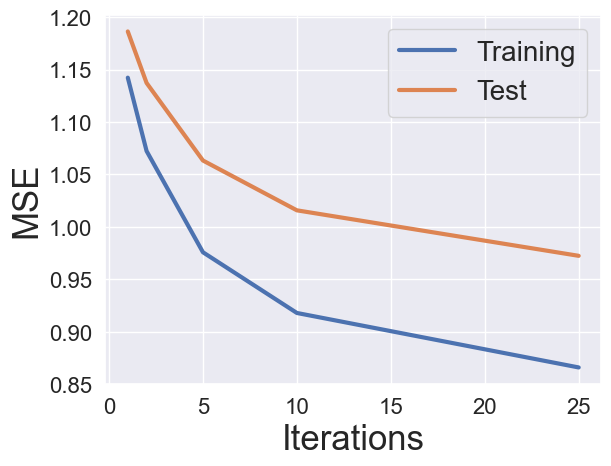

In [ ]:
plot_learning_curve(iter_array, MF_SGD)

In [ ]:
# SDG method with bias needs slightly more time. Bias affect on mse metric sharper, 
# so on this plot we can see the overfitting proccess from 10 iterations.

#### ALS without biases

In [ ]:
start_time = time.time()

MF_ALS = ExplicitMF(train, 40, learning='als', verbose=True, item_fact_reg=0.01,
                                                             user_fact_reg=0.01,
                                                             item_bias_reg=0.01,
                                                             user_bias_reg=0.01,  bias_use=False)
iter_array = [1, 2, 5, 10, 25]
MF_ALS.calculate_learning_curve(iter_array, test, learning_rate=0.001)

end_time = time.time()

print("time: ", end_time - start_time)

Iteration: 1
MSE train:test: 5.42 : 9.64

Iteration: 2
MSE train:test: 4.21 : 8.59

Iteration: 5
MSE train:test: 3.98 : 8.45

Iteration: 10
	current iteration: 10
MSE train:test: 3.94 : 8.41

Iteration: 25
	current iteration: 20
MSE train:test: 3.93 : 8.39

time:  1521.123195886612


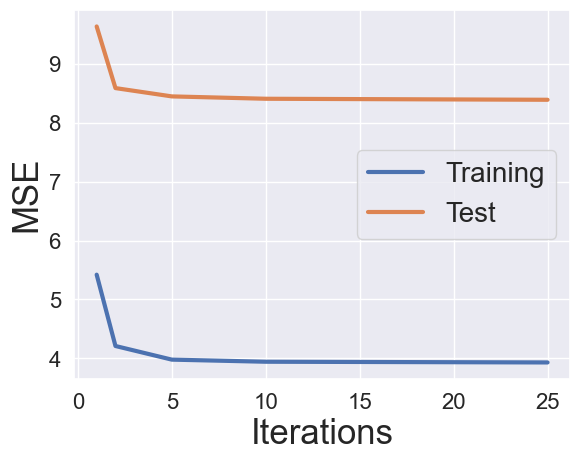

In [ ]:
plot_learning_curve(iter_array, MF_ALS)

In [ ]:
# ALS without bias is needed to be rewritten to matrix numpy calculation. Without it, the time of learning worse in times.
# The overfitting problem also present. I tried regularisation and with it the algorithm works better. 
# With more experiments of this parameter we can decrease the gap between train and test samples in mse metric.

#### ALS with biases

In [ ]:
import time

start_time = time.time()

MF_ALS = ExplicitMF(train, 40, learning='als', verbose=True, bias_use=True)
iter_array = [1, 2, 5, 10, 25]
MF_ALS.calculate_learning_curve(iter_array, test, learning_rate=0.001)

end_time = time.time()

print("time: ", end_time - start_time)

Iteration: 1
MSE train:test: 0.44 : 10.36

Iteration: 2
MSE train:test: 0.36 : 9.47

Iteration: 5
MSE train:test: 0.34 : 9.39

Iteration: 10
	current iteration: 10
MSE train:test: 0.34 : 9.41

Iteration: 25
	current iteration: 20
MSE train:test: 0.34 : 9.43

time:  969.7083077430725


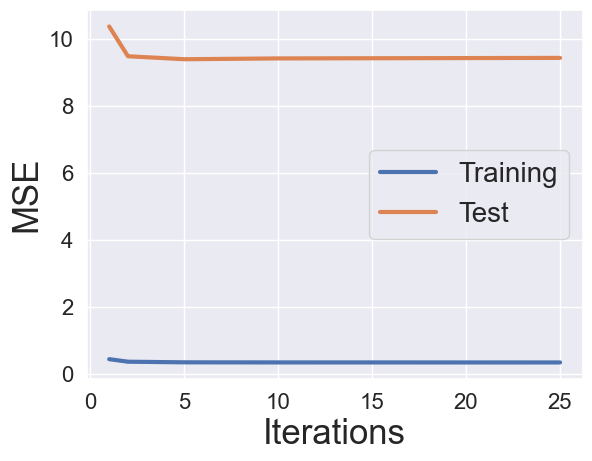

In [ ]:
# with bias in prediction
plot_learning_curve(iter_array, MF_ALS)

In [ ]:
# ALS with bias shows huge impact on train part. The time of work depends from avaliable computation resources. 
# (And my other computations for deep learning homeworks) 
# I noticed that without seperated machine i can't honestly compare experiments on time metric. Well, then we just remember 
# that if we use own realisations, we will need to optimaze them or use already written realisations like pyspark.ml 
# where i got simmilar results

In [5]:
!PYSPARK_HADOOP_VERSION=3 pip install pyspark

In [5]:
import os
import pandas as pd
from pyspark.sql import SparkSession
import sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [6]:
spark = SparkSession.builder.appName('ML_ALS').getOrCreate()

In [7]:
spark.sparkContext

<SparkContext master=local[*] appName=ML_ALS>

In [8]:
movielens = spark.sparkContext.textFile("./u.data")

In [9]:
mls = movielens.map(lambda l: l.split('\t'))

In [10]:
from pyspark.mllib.recommendation import ALS, Rating

In [11]:
ratings = mls.map(lambda x: Rating(int(x[0]), int(x[1]), float(x[2])))

In [12]:
ps_train, ps_test = ratings.randomSplit([0.7, 0.3])

In [13]:
import time

start_time = time.time()

latent = 40
numIterations = [1, 2, 5, 10]
for numIteration in numIterations:
    print("NUM Iteration: ", numIteration)
    model = ALS.train(ps_train, latent, numIteration, 0.001)

    train_pred_input = ps_train.map(lambda x:(x[0], x[1]))
    test_pred_input = ps_test.map(lambda x:(x[0], x[1]))

    train_pred = model.predictAll(train_pred_input)
    test_pred = model.predictAll(test_pred_input)

    # (user, product) the key)
    train_true_est = ps_train.map(lambda x:((x[0],x[1]), x[2]))
    test_true_est = ps_test.map(lambda x:((x[0],x[1]), x[2]))

    train_pred_est = train_pred.map(lambda x:((x[0],x[1]), x[2]))
    test_pred_est = test_pred.map(lambda x:((x[0],x[1]), x[2]))

    train_all_est = train_true_est.join(train_pred_est)
    test_all_est = test_true_est.join(test_pred_est)

    train_mse = train_all_est.map(lambda r: (r[1][0] - r[1][1])**2).mean()
    test_mse = test_all_est.map(lambda r: (r[1][0] - r[1][1])**2).mean()

    print(f'MSE train:test: {round(train_mse,2)} : {round(test_mse,2)}\n')

end_time = time.time()
print("time: ", end_time - start_time)

NUM Iteration:  1
MSE train:test: 1.7 : 14.58

NUM Iteration:  2
MSE train:test: 0.23 : 2.42

NUM Iteration:  5
MSE train:test: 0.09 : 2.35

NUM Iteration:  10
MSE train:test: 0.06 : 2.47

time:  109.35294842720032


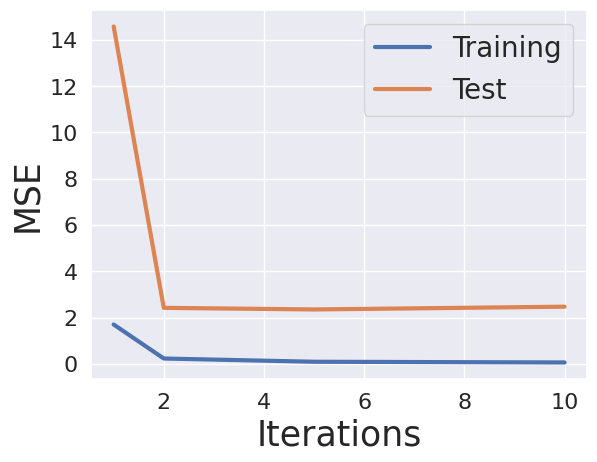

In [14]:
iter_array = [1, 2, 5, 10]
train_mse_ = [1.7, 0.23, 0.09, 0.06]
test_mse_ = [14.58, 2.42, 2.35, 2.47]

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.plot(iter_array, train_mse_, \
          label='Training', linewidth=3)
plt.plot(iter_array, test_mse_, \
          label='Test', linewidth=3)


plt.xticks(fontsize=16);
plt.yticks(fontsize=16);
plt.xlabel('Iterations', fontsize=25);
plt.ylabel('MSE', fontsize=25);
plt.legend(loc='best', fontsize=20);

In [ ]:
# Pyspark realisation still worse than SGD realisation by time, 
# however it has best metric perfomance with simillar overfitting problem

In [ ]:
# So, there are several reasons why an ALS implementation may lead to poor performance when evaluated using MSE:
# the initial values assigned to the latent factors can significantly impact convergence and final accuracy.
# The complexity of the model, determined by the rank of the factor matrices, must match the underlying structure 
# of the data. Too low rank leads to underfitting, while too high a rank can lead to overfitting, 
# both results increasing MSE.

# Also choosing appropriate hyperparameters such as regularization strength, learning rate, and number of iterations 
# is crucial. Poorly tuned parameters can result in poor metric.
# Over-regularization can lead to overly smoothed predictions that do not capture the true patterns in the data, 
# whereas under-regularization allows the model to fit noise.